# Compute time of entry and plot the comaparision among various networks  (In progress)
1. Import necessary requirements  
2. Load node community data  
3. Compute Time of Entry of nodes based on first time they enter the main cluster
4. Arrange nodes by their communities and plot them  
5. Use Avinash color scheme for communities as well as different colors for plots

#### 1. Import necessary requirements

In [1]:
from tes.analysis import AnalysisFunc
from tes.data_ingestion import DataRead

from pathlib import Path
import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Make objects

In [2]:
analyse=AnalysisFunc()
reader = DataRead()

#### 2. Load node community data 

In [3]:
data_folder = Path("../../data/server_data/node_communities")

# Use glob to match files with a pattern
files = glob.glob(str(data_folder / "nc*.bz2"))

#### 3. Compute Time of Entry of nodes based on first time they enter the main cluster

In [25]:
#delete this after exploration
test_nc=reader.data_read_bz2('server_data/node_communities/nc_fn.bz2')
# test_df=test_nc.reset_index()
# # test_df['level_0'].drop_duplicates()
# test_nc.loc[1]
# list(test_df['level_0'].drop_duplicates())
mc=analyse.compute_main_cluster(test_nc.loc[1])
mc2=analyse.compute_main_cluster(test_nc.loc[2])
a=analyse.compute_toe(test_nc.loc[1],mc)
b=analyse.compute_toe(test_nc.loc[2],mc2)
l=[]
l.append(a)

In [4]:

toe=[]  # to store toe per noce community data
mean_toe=[]
label=[]

for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df = pd.read_pickle(f, compression="bz2")
    df_ind = df.reset_index()
    n_itr=list(df_ind['level_0'].drop_duplicates())

    for i in n_itr:
        mc=analyse.compute_main_cluster(df.loc[i])
        t_itr=analyse.compute_toe(df.loc[i],mc)
        toe.append(t_itr)
    label.append(name_suffix)
    col_mean=np.mean(np.array(toe),axis=0)
    mean_toe.append(col_mean)

# Sorting by communities
desired_order=list(reader.get_communities().index)
mean_toe=np.array(mean_toe)
mean_toe_rearr=mean_toe[:,desired_order]
df_toe=pd.DataFrame(mean_toe_rearr,index=label).T

In [5]:
toe_plot_data=pd.concat([reader.get_communities().to_frame(),df_toe],axis=1)

In [19]:
toe_plot_data

,0,bla,enti,fn,orb,peri,pir,re
0,MO,2798.529412,2832.763158,2587.586207,2328.897436,2399.214286,2397.806723,2425.007299
1,MO,3738.529412,3818.973684,3834.982759,3768.410256,3795.316327,3797.512605,3817.715328
2,MO,3489.058824,3495.710526,3551.551724,3475.089744,3477.102041,3479.210084,3501.386861
3,MO,3632.588235,3463.026316,3280.551724,3207.076923,3253.673469,3246.655462,3282.912409
4,MO,3546.117647,3583.184211,3475.068966,3497.653846,3533.112245,3529.403361,3546.328467
...,...,...,...,...,...,...,...,...
421,HIND,1897.235294,1907.210526,1687.206897,1616.974359,1689.448980,1739.462185,1695.043796
422,HIND,4242.823529,4409.657895,4589.517241,4665.730769,4670.775510,4657.873950,4679.656934
423,HIND,4999.000000,4984.921053,4989.775862,4973.628205,4953.163265,4953.369748,4959.364964
424,HIND,4949.176471,4690.763158,4715.258621,4696.346154,4719.918367,4724.647059,4739.970803


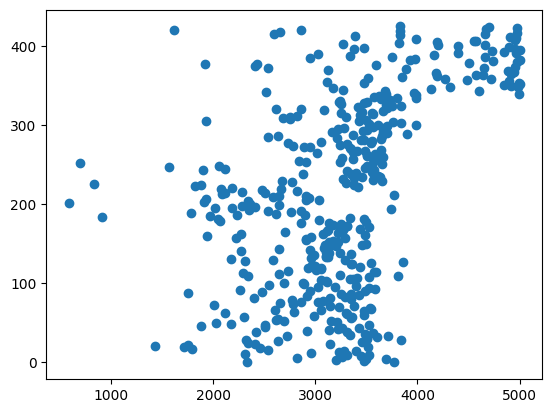

In [15]:
plt.scatter(toe_plot_data['orb'],list(toe_plot_data.index))

In [22]:
node_order = np.array(['FN', 'PERI', 'RE', 'ENTI', 'ORB', 'BLA', 'PIR'])
node_c_avi =  ["#00FFFF","#0000FF", "#ADD8E6", "#0000CD", "#808000", "#008000", "#006400", "#8B4513"]
node_c_nim = ['#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080']
color_seq =['ORB', 'MO', 'VIS', 'OLF', 'HTh', 'HIPP','MID','HIND']

node_c_avi = dict(zip(color_seq, node_c_avi))
node_c_nim = dict(zip(color_seq, node_c_nim))

In [32]:
node_c_nim

{'ORB': '#FF0000',
 'MO': '#00FF00',
 'VIS': '#0000FF',
 'OLF': '#FFFF00',
 'HTh': '#00FFFF',
 'HIPP': '#FF00FF',
 'MID': '#FFA500',
 'HIND': '#800080'}

In [ ]:
colors = [ '#FF0000', '#00FF00',  '#0000FF',  '#FFFF00',  '#00FFFF', '#FF00FF', '#FFA500', '#800080' ]
fig,ax=plt.subplots(figsize=(12,8))
y=toe_plot_data['bla'].groupby([0]).apply()
x=toe_plot_data.shape[0]
ax.scatter(x,y,color=)